## content

In [27]:
# NOTE:

## importing the libraries

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## importing the datasets

In [29]:
dataset=pd.read_csv('Position_Salaries.csv')

x = dataset.iloc[:, 1:-1].values # here we have three columns , we are are taking from second to last bfore(-1--> predictio)

y=dataset.iloc[:,-1].values # takes onlylast column



In [30]:
print(x)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [31]:
print(y)

[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [32]:
# reshaping or transforming y  because the feature scaling / standardizarion expects a unique feature --> when fit.transform is applied it asks for 2d array  not 1D (ERROR)
y= y.reshape(len(y),1) #row and column 
print(y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


## Feature scaling

In [33]:
from sklearn.preprocessing import StandardScaler
sc_x=StandardScaler()
sc_y=StandardScaler()
x=sc_x.fit_transform(x)
y=sc_y.fit_transform(y) # scaling both features so creating two standard scaler onbject (x,y)

In [34]:
print(x)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]


In [35]:
print(y) # standardization(-3,3)

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


In [36]:
# we will not seperate the datasets as train and test , because

## training the SVR model on the whole dataset

In [37]:
# taking whole dataset 
from sklearn.svm import SVR
svr_obj= SVR(kernel='rbf') # parameter kernel = rbf(non linear kernel)

#train
svr_obj.fit(x,y)


c:\Users\finis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [38]:
# we have scaled both x, y 

## predicting a new result

In [39]:
# we have scaled both x, y (sc-x,sc_y)
#  so to get original value  we are using inverse tranforming y  (rescale(revser scaling to the output of y))

In [41]:
sc_y.inverse_transform(svr_obj.predict(sc_x.transform([[6.5]])).reshape(-1,1))

array([[170370.0204065]])

## visualizing the SVR results

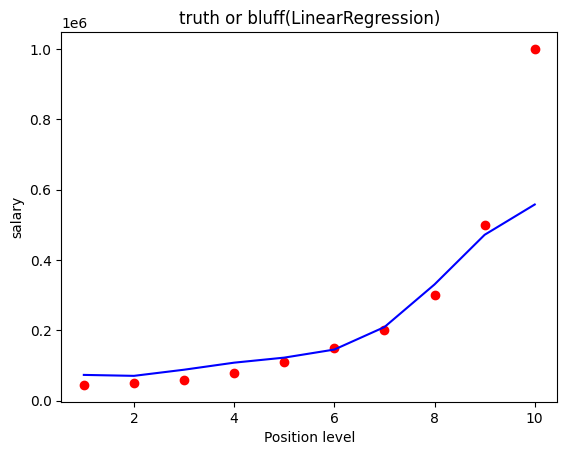

In [42]:
plt.scatter(sc_x.inverse_transform(x),sc_y.inverse_transform(y),color = 'red') # we scaled x and y , so inorder to get both values we are rescaling both x,y 
plt.plot(sc_x.inverse_transform(x),sc_y.inverse_transform(svr_obj.predict(x).reshape(-1,1)),color= 'blue')# x cordinate and  y-->predicted value code 
plt.title('truth or bluff(LinearRegression)')
plt.xlabel('Position level')
plt.ylabel('salary')
plt.show()

## visualizing thr SVR results(for higher resokutionand smoother curve)

In [43]:
x_grid = np.arange(min(sc_x.inverse_transform(x)), max(sc_x.inverse_transform(x)), 0.1) #scales values inserting
x_grid = x_grid.reshape(len(x_grid), 1)
plt.scatter(sc_x.inverse_transform(x),sc_y.inverse_transform(y), color='red')
plt.plot(x_grid,sc_y.inverse_transform(svr_obj.predict(sc_x.transform(x_grid))), color='blue')
plt.title('Truth or Bluff (SVR Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

TypeError: only 0-dimensional arrays can be converted to Python scalars

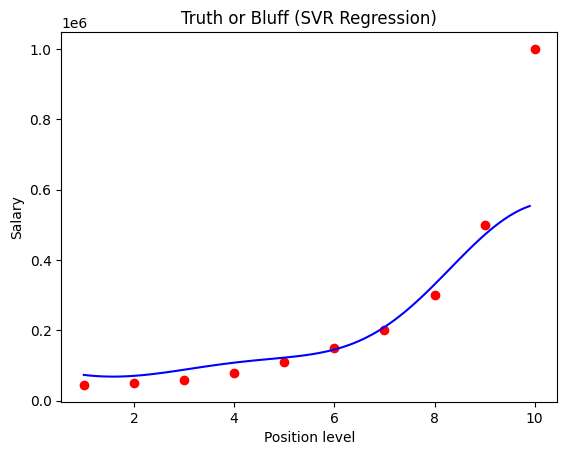

In [44]:
x_grid = np.arange(
    min(sc_x.inverse_transform(x)).item(),
    max(sc_x.inverse_transform(x)).item(),
    0.1
)

x_grid = x_grid.reshape((len(x_grid), 1))

plt.scatter(
    sc_x.inverse_transform(x),
    sc_y.inverse_transform(y.reshape(-1, 1)),
    color='red'
)

plt.plot(
    x_grid,
    sc_y.inverse_transform(
        svr_obj.predict(sc_x.transform(x_grid)).reshape(-1, 1)
    ),
    color='blue'
)

plt.title('Truth or Bluff (SVR Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()